In [1]:
import random
from IPython.display import clear_output
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
class Simulator:

    def __init__(self, n_options, your_answer = 0):
        self.n_options = n_options
        self.your_answer = your_answer

        self.random_answer_correct = 0
        self.your_answer_correct = 0
        self.num_questions_your = 0
        self.num_questions_random = 0

    @property
    def your_accuracy(self):
        return self.your_answer_correct / self.num_questions_your

    @property
    def random_accuracy(self):
        return self.random_answer_correct / self.num_questions_random 

    def ask_question(self):
        self.options = list(range(self.n_options))
        self.answer = random.choice(self.options)
        return self.options, self.answer

    def _check_your_answer(self):
        self.ask_question()
        if self.your_answer == self.answer:
            self.your_answer_correct += 1
            self.num_questions_your += 1
        else:
            self.num_questions_your += 1

    def _check_random_answer(self):
        random_answer = random.choice(self.options)

        if random_answer == self.answer:
            self.random_answer_correct += 1
            self.num_questions_random += 1
        else:
            self.num_questions_random += 1

    def start(self, num_questions =10, verbose = True):
        for _ in range(num_questions):
            self._check_your_answer()
            self._check_random_answer()

        if verbose:
            print("Result while ticking single option everytime: {}/{}".format(self.your_answer_correct, self.num_questions_your))
            print("Result while guessing randomly: {}/{}".format(self.random_answer_correct, self.num_questions_random))

In [4]:
s = Simulator(4)
s.start(10)

Result while ticking single option everytime: 3/10
Result while guessing randomly: 4/10


In [5]:
your_accuracy = 0
random_accuracy = 0
n=1000

for _ in range(n):
    s=Simulator(4)
    s.start(10, verbose=False)
    your_accuracy += s.your_accuracy
    random_accuracy += s.random_accuracy

print("Average accuracy while ticking first option every time: {}".format(round(your_accuracy/n,4)))
print("Average accuracy while guessing randomly: {}".format(round(random_accuracy/n,4)))

if your_accuracy > random_accuracy:
    print("Your accuracy is better than random accuracy")
else:
    print("Random accuracy is better than your accuracy")

Average accuracy while ticking first option every time: 0.2482
Average accuracy while guessing randomly: 0.249
Random accuracy is better than your accuracy


In [6]:
def get_average(num_iteration, **kwargs):
    your_accuracy = 0
    random_accuracy = 0

    for _ in range(num_iteration):
        s=Simulator(4)
        s.start(**kwargs)
        your_accuracy += s.your_accuracy
        random_accuracy += s.random_accuracy

    # print("Average accuracy while ticking first option every time: {}".format(round(your_accuracy/num_iteration,4)))
    # print("Average accuracy while guessing randomly: {}".format(round(random_accuracy/num_iteration,4)))
    if your_accuracy > random_accuracy:
        # print("Your accuracy is better than random accuracy")
        return 0
    else:
        # print("Random accuracy is better than your accuracy")
        return 1

In [7]:
get_average(100, num_questions=1, verbose=False)

1

In [25]:
# random.seed(42)
random_better = 0
your_better = 0
result_dict = {
    1:[],
    2:[],
    3:[],
    4:[],
    5:[],
    6:[],
    7:[],
    8:[],
    9:[],
    10:[],
    15:[],
    20:[],
    25:[],
    30:[],
    50:[],
    100:[],
}
for n in result_dict.keys():
    print("Simulating with {} questions".format(n))
    clear_output(wait=True)
    for i in range(5):
        print(f"Iteration {i+1} for {n} questions")

        for _ in range(1000):
            result = get_average(100, num_questions=n, verbose=False)
            if result:
                random_better += 1
            else:
                your_better += 1
        random_accuracy = round(random_better / (random_better + your_better),4)
        your_accuracy = round(your_better / (random_better + your_better),4)
        result_dict[n].append((random_accuracy, your_accuracy))

Iteration 1 for 100 questions
Iteration 2 for 100 questions
Iteration 3 for 100 questions
Iteration 4 for 100 questions
Iteration 5 for 100 questions


In [26]:
df1 = pd.DataFrame(result_dict)
df = df1.T

In [27]:
def cal_mean(row):
    sum = 0
    for item in row:
        sum += item[0]
    return sum/len(row)

def cal_mean2(row):
    sum = 0
    for item in row:
        sum += item[1]
    return sum/len(row)

In [28]:
df["Random"] = df1.apply(cal_mean)
df["Fixed"] = df1.apply(cal_mean2)

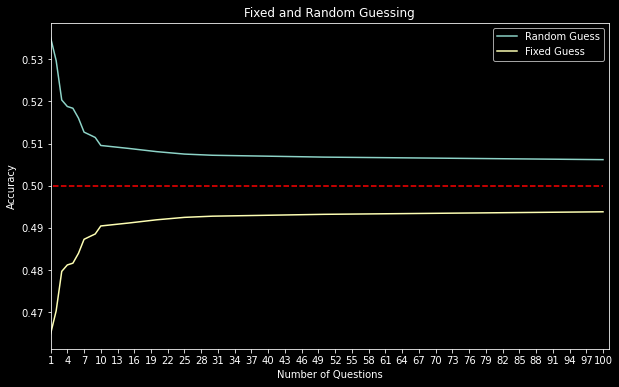

In [29]:
plt.figure(figsize=(10,6))
plt.plot(df["Random"], label="Random Guess")
plt.plot(df["Fixed"], label="Fixed Guess")
plt.xlabel("Number of Questions")
plt.ylabel("Accuracy")
plt.title("Fixed and Random Guessing")
plt.hlines(0.5, 0, 100, colors="r", linestyles="dashed")
plt.xlim(1,101)
plt.xticks(range(1,101,3))
plt.legend();